In [1]:
import os
import torch
import numpy as np
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 20})
matplotlib.rcParams['font.family'] = 'Times New Roman'

In [ ]:
# priors
path = 'FLUX/outputs/priors/priors.pt'
priors = torch.load(path)

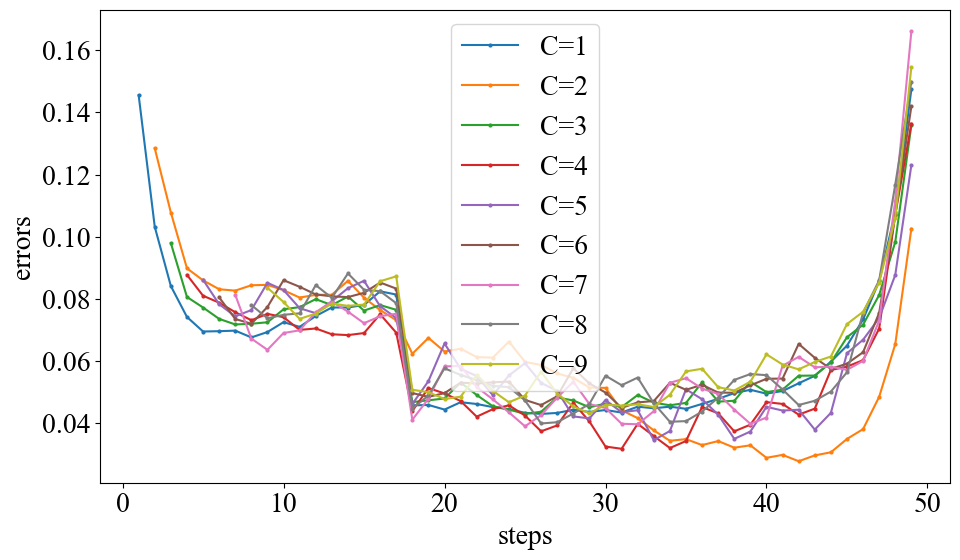

In [9]:
# each C=i visualization
fig, ax = plt.subplots(figsize=(10, 6))
for k, v in priors.items():
    arr = v.detach().cpu().float().numpy()
    arr = np.squeeze(arr)
    # arr = np.flip(arr)
    flat = np.ravel(arr)
    idx = np.arange(flat.size)
    mask = flat != 0
    ax.plot(idx[mask], flat[mask], '.-', label=k, markersize=4)

ax.legend()
# clamp to avoid outlier
# ax.set_ylim(0,0.015)
ax.set_xlabel('steps')
ax.set_ylabel('errors')
plt.tight_layout()
plt.show()

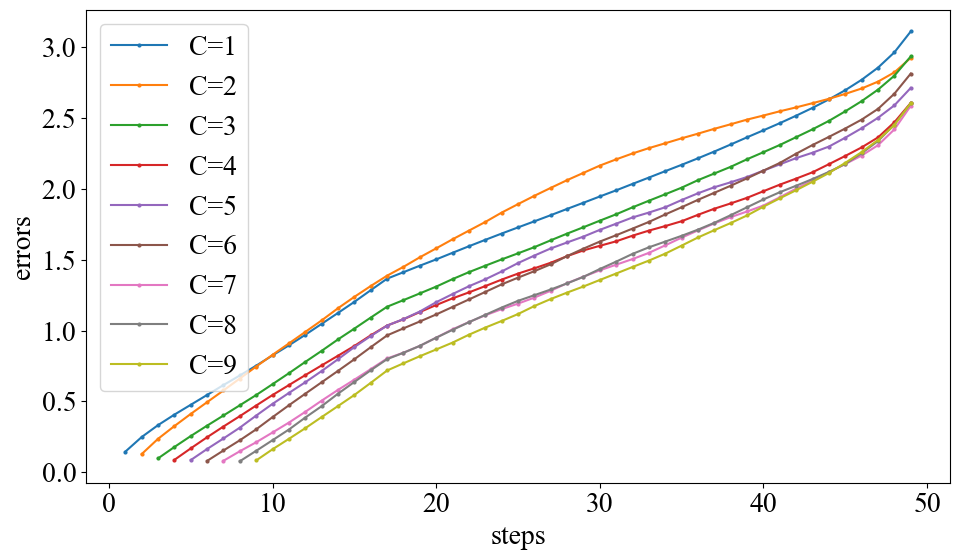

In [10]:
# each C=i with error accumulation visualization
fig, ax = plt.subplots(figsize=(10, 6))
for k, v in priors.items():
    arr = v.detach().cpu().float().numpy()
    arr = np.squeeze(arr)
    # arr = np.flip(arr)
    flat = np.ravel(arr)
    flat = np.cumsum(flat)
    idx = np.arange(flat.size)
    mask = flat != 0
    ax.plot(idx[mask], flat[mask], '.-', label=k, markersize=4)

ax.legend()
# clamp to avoid outlier
# ax.set_ylim(0,0.3)
ax.set_xlabel('steps')
ax.set_ylabel('errors')
plt.tight_layout()
plt.show()

/tmp/ipykernel_915117/1962461.py:14: RuntimeWarning: Mean of empty slice
  global_trend = np.nanmean(global_trend, axis=0)
/tmp/ipykernel_915117/1962461.py:17: RuntimeWarning: Mean of empty slice
  global_trend2 = np.nanmean(global_trend2, axis=0)


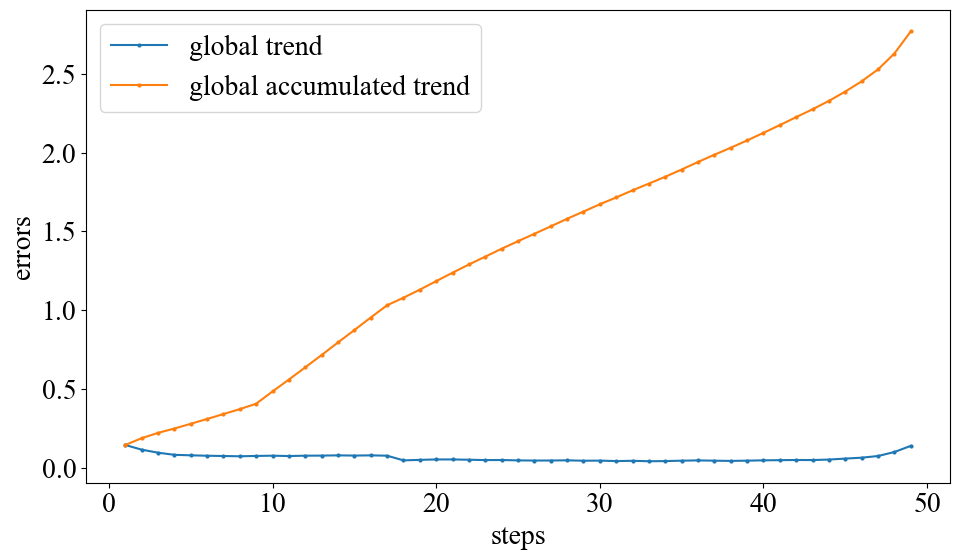

error correction: (array([ 2,  3,  4,  5,  6,  7, 10, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26,
       28, 29, 30, 31, 32, 33, 37]),)
error correction: (array([], dtype=int64),)


In [ ]:
# global trend
global_trend = []
global_trend2 = []
for k,v in priors.items():
    arr = v.detach().cpu().float().numpy()
    arr = np.squeeze(arr)
    # arr = np.flip(arr)
    arr = np.ravel(arr)
    global_trend.append(arr)
    # arr = np.cumsum(arr)
    # global_trend2.append(arr)
global_trend = np.stack(global_trend, axis=0)
global_trend = np.where(global_trend == 0, np.nan, global_trend)
global_trend = np.nanmean(global_trend, axis=0)
# global_trend2 = np.stack(global_trend2, axis=0)
# global_trend2 = np.where(global_trend2 == 0, np.nan, global_trend2)
# global_trend2 = np.nanmean(global_trend2, axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
idx = np.arange(global_trend.size)
ax.plot(idx, global_trend, '.-', label='global trend', markersize=4)
# ax.plot(idx, global_trend2, '.-', label='global accumulated trend', markersize=4)
ax.legend()
# ax.set_ylim(0,0.1)
ax.set_xlabel('steps')
ax.set_ylabel('errors')
plt.tight_layout()
plt.show()

print('error correction:', np.where(np.gradient(global_trend)<=0))
# print('error correction:', np.where(np.gradient(global_trend2)<=0))